# Laboratorio 10 - Visión Por Computadora

Autores:

- Nelson García
- Joaquín Puente
- Diego Linares

Link al repositorio: https://github.com/Its-Japo/VisionXComputadora/tree/main/Lab_10

# Task 1

En clase explicamos que la Difusión "esculpe" la imagen restando ruido de un tensor dentro del Espacio
Latente, paso a paso, antes de que el Decoder la convierta en píxeles. Usted deberá demostrar este
comportamiento interrumpiendo el proceso para observar la evolución temporal.

Instalar librerías necesarias:

In [1]:
!pip -q install -U diffusers transformers accelerate safetensors huggingface_hub matplotlib "pillow<12"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 89.1 MB/s eta 0:00:00


In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("Activa GPU en Colab: Entorno de ejecución > Cambiar tipo de entorno > GPU")

PyTorch: 2.10.0+cu128
CUDA disponible: True
GPU: Tesla T4


In [3]:
#   Cargar Stable Diffusion 1.5 en GPU

from diffusers import StableDiffusionPipeline
from pathlib import Path
import matplotlib.pyplot as plt

device = "cuda"
model_id = "stable-diffusion-v1-5/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    use_safetensors=True
)

pipe = pipe.to(device)

# Ayuda a reducir memoria en Colab.
pipe.enable_attention_slicing()

print("Modelo cargado en:", pipe.device)
print("VAE scaling factor:", pipe.vae.config.scaling_factor)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Modelo cargado en: cuda:0
VAE scaling factor: 0.18215


In [4]:
#Interceptar los latentes en los pasos 4, 10, 16 y 20

prompt = "A highly detailed cinematic and futuristic fruit glowing in a cyberpunk laboratory, neon lights, 4k resolution"

num_inference_steps = 20
seed = 2026

# Se fija la semilla global y también el generador CUDA.
torch.manual_seed(seed)
generator = torch.Generator(device=device).manual_seed(seed)

capture_steps = {4, 10, 16, 20}
latents_by_step = {}

def capture_latents_callback(pipe, step_index, timestep, callback_kwargs):
    """
    step_index viene indexado desde 0.
    Por eso step_number = step_index + 1.
    """
    step_number = step_index + 1

    if step_number in capture_steps:
        latents = callback_kwargs["latents"]

        # Guardamos copia exacta en CPU para no modificar el proceso.
        latents_by_step[step_number] = latents.detach().clone().cpu()

        print(
            f"Latente guardado en paso {step_number:02d} | "
            f"shape={tuple(latents.shape)} | dtype={latents.dtype}"
        )

    return callback_kwargs

In [5]:
#Ejecutar el pipeline sin decodificar automáticamente la imagen final

with torch.inference_mode():
    _ = pipe(
        prompt=prompt,
        num_inference_steps=num_inference_steps,
        guidance_scale=7.5,
        generator=generator,
        callback_on_step_end=capture_latents_callback,
        callback_on_step_end_tensor_inputs=["latents"],
        output_type="latent"
    )

print("Pasos capturados:", sorted(latents_by_step.keys()))

  0%|          | 0/20 [00:00<?, ?it/s]

Latente guardado en paso 04 | shape=(1, 4, 64, 64) | dtype=torch.float16
Latente guardado en paso 10 | shape=(1, 4, 64, 64) | dtype=torch.float16
Latente guardado en paso 16 | shape=(1, 4, 64, 64) | dtype=torch.float16
Latente guardado en paso 20 | shape=(1, 4, 64, 64) | dtype=torch.float16
Pasos capturados: [4, 10, 16, 20]


In [6]:
#Decodificar manualmente cada latente

def decode_latent_to_pil(latent_cpu, pipe):
    """
    Recibe un tensor latente guardado en CPU.
    Lo mueve a GPU, aplica el scaling_factor correcto,
    lo decodifica con el VAE y lo convierte a PIL.
    """
    latent = latent_cpu.to(device=pipe.device, dtype=pipe.vae.dtype)

    # Desescalado requerido antes del VAE.
    latent = latent / pipe.vae.config.scaling_factor

    with torch.inference_mode():
        image_tensor = pipe.vae.decode(latent, return_dict=False)[0]

    # Convierte tensor [-1, 1] a imagen PIL.
    image_pil = pipe.image_processor.postprocess(
        image_tensor,
        output_type="pil"
    )[0]

    return image_pil

In [7]:
out_dir = Path("resultados_task_1")
out_dir.mkdir(exist_ok=True)

decoded_images = {}

for step in [4, 10, 16, 20]:
    img = decode_latent_to_pil(latents_by_step[step], pipe)
    decoded_images[step] = img

    save_path = out_dir / f"latente_decodificado_paso_{step:02d}.png"
    img.save(save_path)

    print("Guardada:", save_path)

Guardada: resultados_task_1/latente_decodificado_paso_04.png
Guardada: resultados_task_1/latente_decodificado_paso_10.png
Guardada: resultados_task_1/latente_decodificado_paso_16.png
Guardada: resultados_task_1/latente_decodificado_paso_20.png


Mostrar resultados:

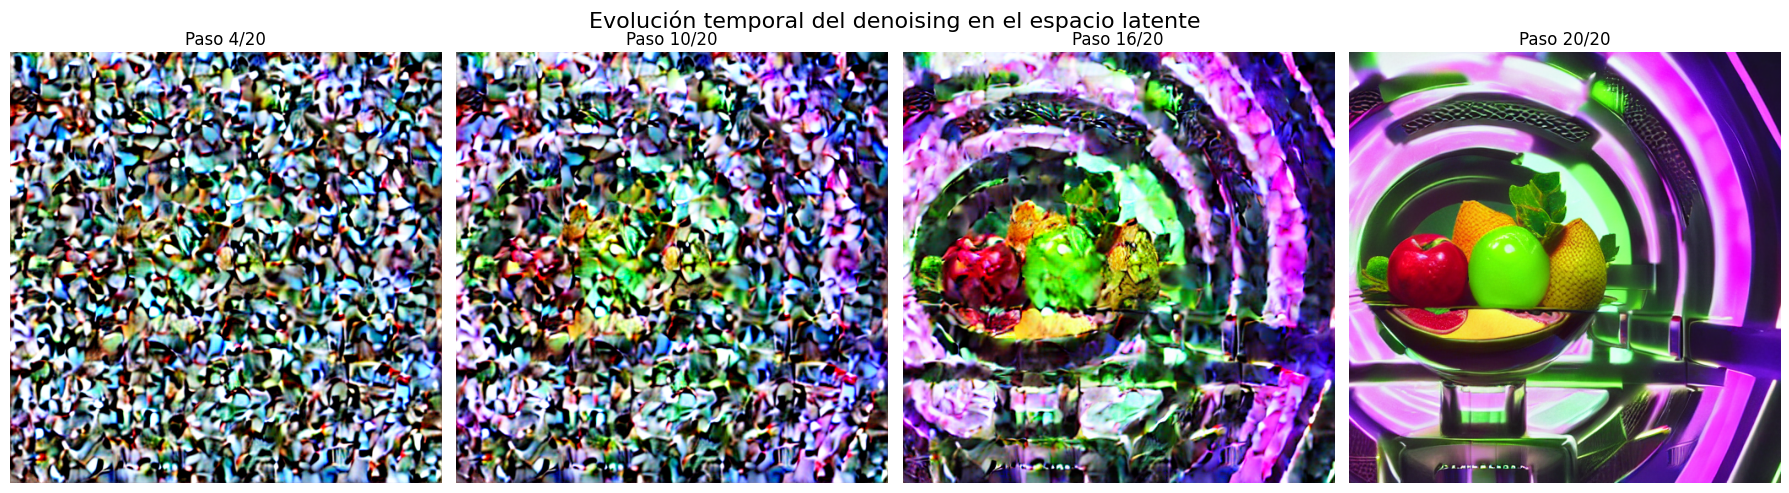

Cuadrícula guardada en: resultados_task_1/grid_evolucion_latentes.png


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, step in zip(axes, [4, 10, 16, 20]):
    ax.imshow(decoded_images[step])
    ax.set_title(f"Paso {step}/20")
    ax.axis("off")

plt.suptitle("Evolución temporal del denoising en el espacio latente", fontsize=16)
plt.tight_layout()

grid_path = out_dir / "grid_evolucion_latentes.png"
plt.savefig(grid_path, dpi=150, bbox_inches="tight")
plt.show()

print("Cuadrícula guardada en:", grid_path)

Observe la diferencia entre la imagen del paso 4 y la del paso 16. Explicado con base en la teoría de
frecuencias espaciales y Cross-Attention: ¿Qué características de la imagen (forma global, colores
bases, silueta vs. brillos, texturas finas, detalles del neón) resuelve la U-Net en las etapas iniciales
de ruido alto, y qué resuelve en las etapas finales de ruido bajo? Justifique técnicamente su
respuesta.

R//

En la comparación entre el paso 4 y el paso 16 se observa que la U-Net no resuelve todos los elementos visuales al mismo tiempo. En las etapas iniciales, cuando el nivel de ruido es alto, el modelo trabaja principalmente sobre componentes de baja frecuencia espacial: distribución general de masas, colores base, iluminación dominante y una posible silueta global. En cambio, en etapas posteriores, cuando el ruido ya es menor, la U-Net refina componentes de alta frecuencia espacial: bordes más definidos, brillos puntuales, texturas finas, detalles del neón y pequeñas variaciones locales.

En el paso 4, la imagen todavía parece una mezcla caótica de patrones, sin una forma semántica clara. Técnicamente, esto ocurre porque el tensor latente conserva mucho ruido y las altas frecuencias están dominadas por variaciones aleatorias. Por eso, la U-Net solo puede empezar a establecer una estructura global: zonas generales de color, contrastes amplios y una distribución aproximada de la composición. En esta etapa se empiezan a sugerir colores compatibles con el prompt, como verdes, magentas, cianes y tonos brillantes asociados al estilo cyberpunk, pero aún no aparecen detalles confiables de la fruta ni del laboratorio.

Desde la teoría de frecuencias espaciales, las bajas frecuencias representan cambios suaves y estructuras grandes: fondo, silueta, posición del objeto principal y paleta cromática general. Estas son más fáciles de estabilizar al inicio porque no requieren precisión píxel a píxel. Por eso, en ruido alto, el modelo prioriza la composición global antes que los detalles. La imagen del paso 4 contiene indicios de textura, pero esos patrones no son todavía detalles reales; son principalmente ruido organizado parcialmente.

En el paso 16, la imagen ya muestra una estructura mucho más reconocible. Se percibe una composición central, formas circulares o envolventes, mayor separación entre objeto y fondo, y colores neón más coherentes. Aquí la U-Net ya trabaja con un latente menos ruidoso, por lo que puede resolver frecuencias espaciales más altas: contornos, brillos, reflejos, pequeñas texturas y detalles visuales asociados al laboratorio futurista. Los patrones dejan de ser ruido puro y empiezan a convertirse en detalles semánticamente útiles.

La Cross-Attention guía este proceso porque conecta las palabras del prompt con regiones del latente. En las primeras etapas, términos como fruit, cyberpunk laboratory y neon lights influyen de forma global: ayudan a decidir qué tipo de escena se está formando, qué colores dominarán y dónde podría ubicarse el objeto principal. En las etapas finales, esa atención se vuelve más específica: refuerza detalles locales relacionados con “glowing”, “neon lights”, “highly detailed” y “futuristic”, haciendo que aparezcan brillos, texturas complejas y efectos visuales más finos.

Por lo tanto, la U-Net primero resuelve la estructura de baja frecuencia: forma global, composición, colores base y silueta aproximada. Después, en etapas de menor ruido, resuelve la estructura de alta frecuencia: bordes definidos, texturas finas, reflejos, detalles luminosos y elementos de neón. Esto justifica que el paso 4 se vea más abstracto y ruidoso, mientras que el paso 16 ya presenta una imagen visualmente más organizada y alineada con el prompt.

# Task 2
Como vimos al final de la sesión, el modelo Nano Banana de Google representa la vanguardia en
eficiencia: usar técnicas de destilación para saltarse pasos matemáticos de la Cadena de Markov y correr
modelos generativos en milisegundos. Usted simulará este escenario midiendo empíricamente el trade-off
(costo-beneficio) en producción.